In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = {
    "Overs": [5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
              5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
              5, 10, 15, 20, 25, 30, 35, 40, 45, 50],

    "Runs": [42, 82, 125, 172, 215, 255, 292, 330, 365, 398,
             38, 76, 118, 165, 205, 245, 280, 318, 350, 385,
             45, 88, 132, 180, 225, 265, 305, 342, 378, 410],

    "Wickets": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                0, 1, 2, 3, 4, 5, 6, 7, 8, 9],

    "Run_Rate": [8.4, 8.2, 8.3, 8.6, 8.6, 8.5, 8.3, 8.25, 8.1, 7.96,
                 7.6, 7.6, 7.87, 8.25, 8.2, 8.17, 8.0, 7.95, 7.78, 7.7,
                 9.0, 8.8, 8.8, 9.0, 9.0, 8.83, 8.71, 8.55, 8.4, 8.2],

    "Final_Score": [172, 172, 172, 172, 172, 172, 172, 172, 172, 172,
                    165, 165, 165, 165, 165, 165, 165, 165, 165, 165,
                    180, 180, 180, 180, 180, 180, 180, 180, 180, 180]
}

df = pd.DataFrame(data)

print("Cricket Dataset Created Successfully!")
print("Dataset Shape:", df.shape)
df.head()

Cricket Dataset Created Successfully!
Dataset Shape: (30, 5)


,Overs,Runs,Wickets,Run_Rate,Final_Score
0,5,42,0,8.4,172
1,10,82,1,8.2,172
2,15,125,2,8.3,172
3,20,172,3,8.6,172
4,25,215,4,8.6,172


In [4]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Overs        30 non-null     int64  
 1   Runs         30 non-null     int64  
 2   Wickets      30 non-null     int64  
 3   Run_Rate     30 non-null     float64
 4   Final_Score  30 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 1.3 KB
None

Missing Values:
Overs          0
Runs           0
Wickets        0
Run_Rate       0
Final_Score    0
dtype: int64


In [5]:
print("First 10 Records:")
display(df.head(10))

First 10 Records:


,Overs,Runs,Wickets,Run_Rate,Final_Score
0,5,42,0,8.40,172
1,10,82,1,8.20,172
2,15,125,2,8.30,172
3,20,172,3,8.60,172
4,25,215,4,8.60,172
5,30,255,5,8.50,172
6,35,292,6,8.30,172
7,40,330,7,8.25,172
8,45,365,8,8.10,172
9,50,398,9,7.96,172


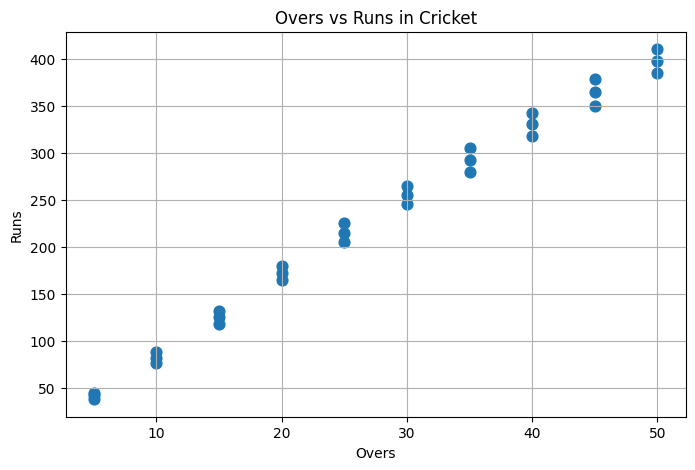

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(df["Overs"], df["Runs"], s=60)

plt.xlabel("Overs")
plt.ylabel("Runs")
plt.title("Overs vs Runs in Cricket")

plt.grid(True)
plt.show()

In [7]:
X = df[["Overs", "Runs", "Wickets", "Run_Rate"]]
y = df["Final_Score"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Overs  Runs  Wickets  Run_Rate
0      5    42        0       8.4
1     10    82        1       8.2
2     15   125        2       8.3
3     20   172        3       8.6
4     25   215        4       8.6

Target:
0    172
1    172
2    172
3    172
4    172
Name: Final_Score, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 4)
Testing Data: (6, 4)


In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [10]:
y_pred = model.predict(X_test)

print("Actual Scores:")
print(y_test.values)

print("\nPredicted Scores:")
print(y_pred)

Actual Scores:
[180 165 180 165 172 172]

Predicted Scores:
[177.1111631  167.43930723 178.93498073 166.22532031 173.7559409
 172.81000566]


In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)
print("R2 Accuracy:", r2 * 100, "%")

Mean Absolute Error: 1.6974050447232212
Mean Squared Error: 3.4451186524166917
Root Mean Squared Error: 1.8561030823789642
R2 Score: 0.9082660713853543
R2 Accuracy: 90.82660713853544 %


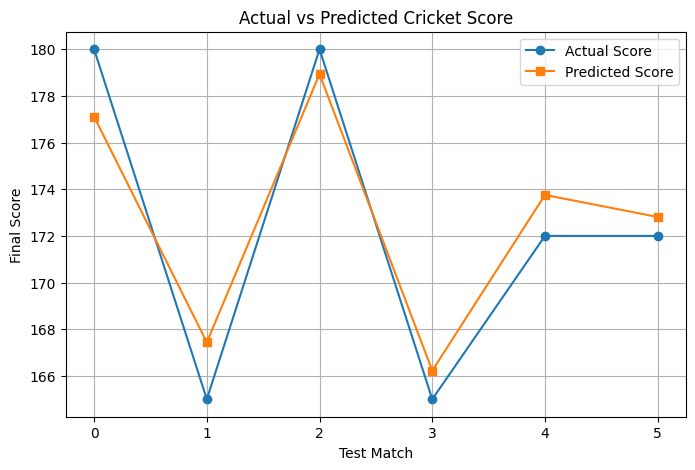

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker='o',
    label="Actual Score"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker='s',
    label="Predicted Score"
)

plt.xlabel("Test Match")
plt.ylabel("Final Score")
plt.title("Actual vs Predicted Cricket Score")

plt.legend()
plt.grid(True)
plt.show()

In [13]:
new_data = pd.DataFrame({
    "Overs": [20],
    "Runs": [150],
    "Wickets": [4],
    "Run_Rate": [7.5]
})

prediction = model.predict(new_data)

print("Cricket Score Prediction")
print("------------------------")
print("Overs:", new_data["Overs"].iloc[0])
print("Current Runs:", new_data["Runs"].iloc[0])
print("Wickets:", new_data["Wickets"].iloc[0])
print("Run Rate:", new_data["Run_Rate"].iloc[0])
print("Predicted Final Score:", round(prediction[0]))

Cricket Score Prediction
------------------------
Overs: 20
Current Runs: 150
Wickets: 4
Run Rate: 7.5
Predicted Final Score: 162


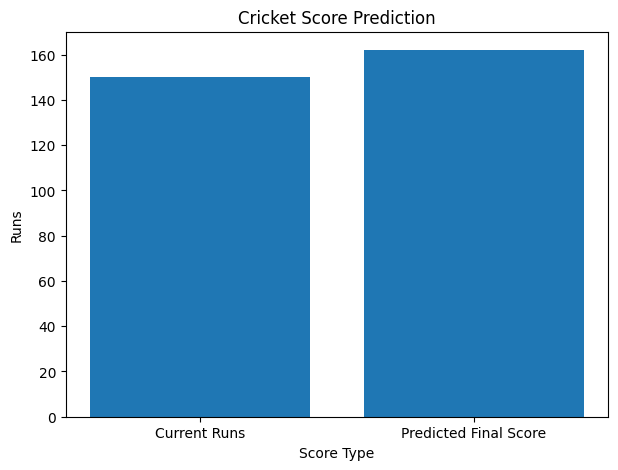

In [14]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Current Runs", "Predicted Final Score"],
    [150, prediction[0]]
)

plt.xlabel("Score Type")
plt.ylabel("Runs")
plt.title("Cricket Score Prediction")

plt.show()